<a href="https://colab.research.google.com/github/spicecat/unhash/blob/main/final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Panorama from overlapping Google Street View images


## Setup

In [1]:
# @title Register Ruff Cell Magic
%pip install ruff -q

from IPython.core.magic import register_cell_magic
import subprocess
import tempfile
import os


@register_cell_magic
def ruff_format(line, cell):
    """Cell magic to format code with ruff. Usage: %%ruff_format"""
    with tempfile.NamedTemporaryFile(mode="w+", delete=False, suffix=".py") as f:
        f.write(cell)
        file_path = f.name
    try:
        subprocess.run(
            ["ruff", "format", file_path], check=True, capture_output=True, text=True
        )
        with open(file_path, "r") as f:
            print(f.read())
    except subprocess.CalledProcessError as e:
        print("Error during formatting:", e.stderr)
    finally:
        os.remove(file_path)


@register_cell_magic
def ruff_lint(line, cell):
    """Cell magic to lint code with ruff. Usage: %%ruff_lint"""
    with tempfile.NamedTemporaryFile(mode="w+", delete=False, suffix=".py") as f:
        f.write(cell)
        file_path = f.name
    try:
        result = subprocess.run(
            ["ruff", "check", file_path], capture_output=True, text=True
        )
        if result.stdout:
            print(result.stdout)
        else:
            print("No issues found.")
    finally:
        os.remove(file_path)


In [2]:
# %pip install opencv-contrib-python matplotlib numpy requests -q

In [3]:
# @title Imports Libraries

import cv2
import matplotlib.pyplot as plt
import numpy as np

## Load Images

In [4]:
# @title Download Images

import os
import requests
import time


def download_images(target_url: str, output_folder="images/", n_images=8, *, seed=0):
    np.random.seed(seed)

    width = 900
    height = 600
    fov = 90

    pitch_range = (-45, 45)
    yaw_range = (0, 360)
    roll_range = (-45, 45)
    step_range = (8, 16)

    pitch = np.random.uniform(*pitch_range) / 2
    yaw = np.random.uniform(*yaw_range)
    roll = np.random.uniform(*roll_range) / 4

    for i in range(n_images):
        params = f"w{width}-h{height}-k-no-pi{pitch}-ya{yaw}-ro{roll}-fo{fov}"
        full_url = f"{target_url}={params}"
        response = requests.get(full_url, stream=True)

        file_path = os.path.join(output_folder, f"{i:02d}_{params}.jpg")
        with open(file_path, "wb") as f:
            for chunk in response.iter_content(1024):
                f.write(chunk)
        print(f"Downloaded: {full_url}")

        pitch += np.random.uniform(*pitch_range) / np.random.uniform(*step_range)
        yaw += 20 + np.random.uniform(*yaw_range) / np.random.uniform(*step_range)
        roll += np.random.uniform(*roll_range) / np.random.uniform(*step_range) / 2

        pitch = (pitch + 90) % 180 - 90
        yaw %= 360
        roll = (roll + 180) % 360 - 180

        time.sleep(0.1)


seed = 0  # @param {"type":"integer","placeholder":"0"}
n_images = 8  # @param {"type":"integer","placeholder":"8"}
target_url = "https://lh3.googleusercontent.com/gpms-cs-s/APRy3c9YvYYbrNABLAJJnx1Ns1VBjpY4Eq6GVt9CRYtmyjGj5L6JmYS9BXmYGK8Ar5uYrH67TJYHXdu87pRJojen4D_dKf7t4PGf8FwEXljW17uLqJCcguGDrAj7of4QqI13EqGTyd4_cQ"  # @param {"type":"string","placeholder":"https://lh3.googleusercontent.com/gpms-cs-s/APRy3c9YvYYbrNABLAJJnx1Ns1VBjpY4Eq6GVt9CRYtmyjGj5L6JmYS9BXmYGK8Ar5uYrH67TJYHXdu87pRJojen4D_dKf7t4PGf8FwEXljW17uLqJCcguGDrAj7of4QqI13EqGTyd4_cQ"}
images_folder = "images/"  # @param {"type":"string","placeholder":"images/"}
if not os.path.exists(images_folder):
    os.makedirs(images_folder)
    download_images(target_url, images_folder, n_images, seed=seed)

In [5]:
# @title Load Images

import glob

image_paths = sorted(glob.glob(os.path.join(images_folder, "*.jpg")))[:n_images]
read_images = [cv2.imread(p) for p in image_paths]
images = [img for img in read_images if img is not None]
print(f"Loaded {n_images} images from {images_folder}")

Loaded 8 images from images/


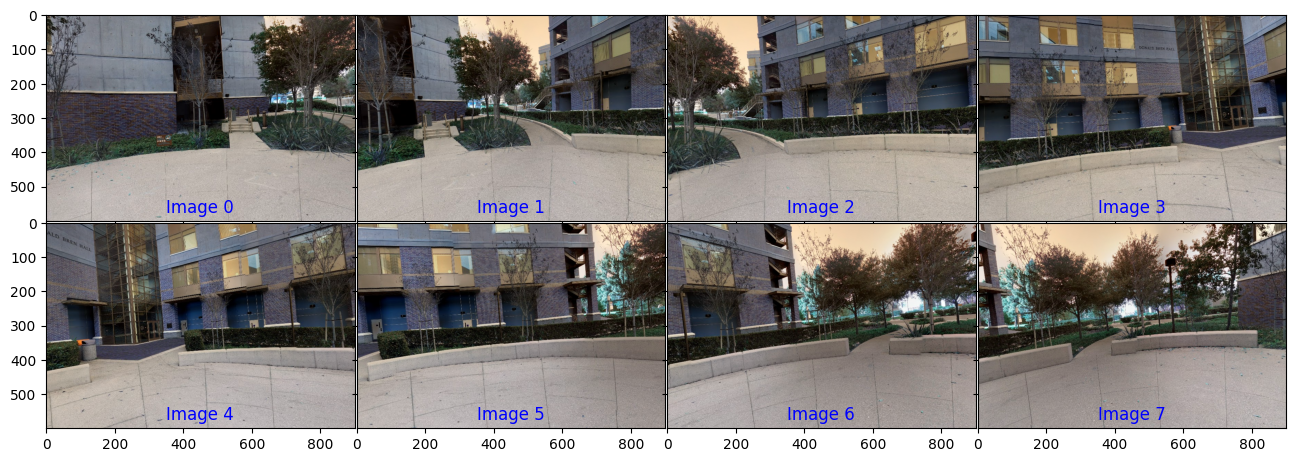

In [6]:
# @title Preview Images

from mpl_toolkits.axes_grid1 import ImageGrid

plt.rcParams["text.color"] = "b"
plt.rcParams["axes.titley"] = 0


def preview_images(images):
    cols = 4
    rows = int(np.ceil(len(images) / cols))
    fig_images = plt.figure(figsize=(4 * cols, 3 * rows))
    grid_images = ImageGrid(fig_images, 111, (rows, cols))

    for i, (ax, img) in enumerate(zip(grid_images, images)):  # pyright: ignore[reportArgumentType, reportGeneralTypeIssues]
        ax.imshow(img)
        ax.set_title(f"Image {i}")


preview_images(images)

## Stitcher Baseline

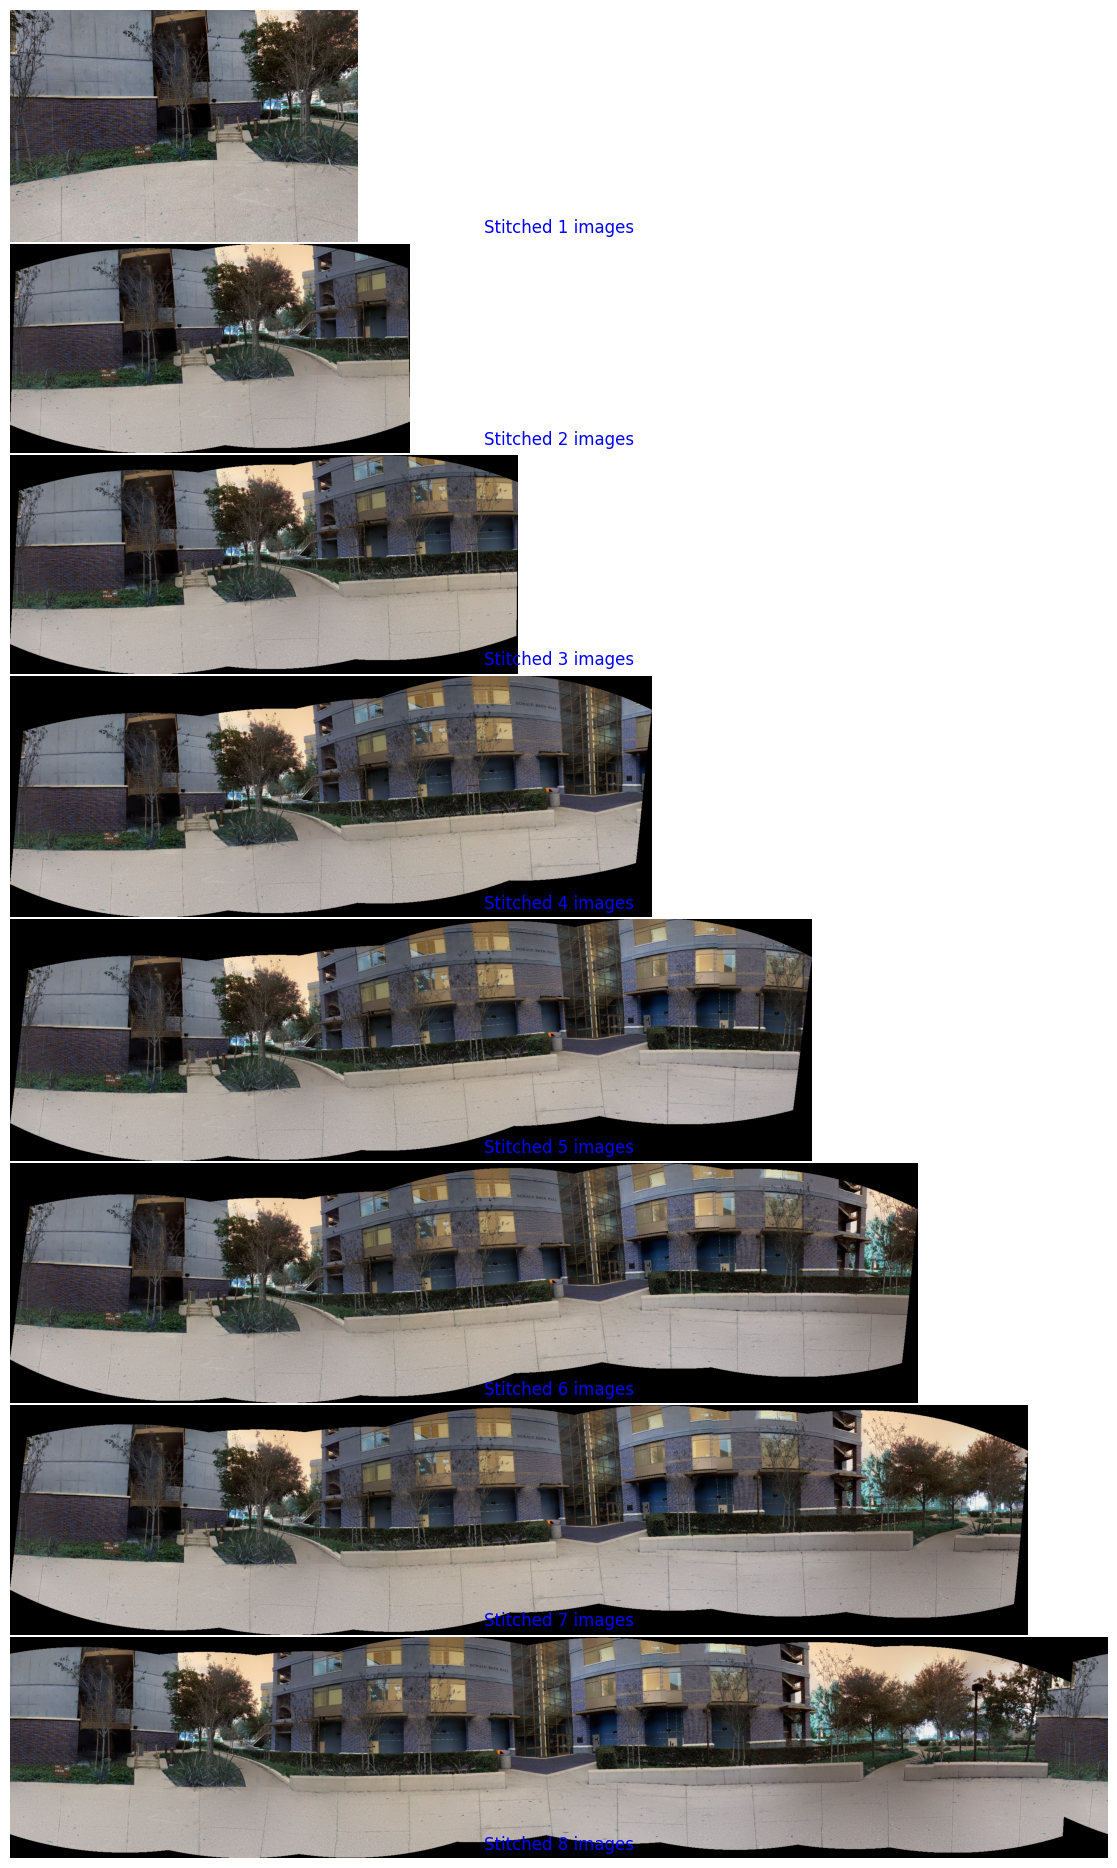

In [7]:
# @title Stitcher

stitcher = cv2.Stitcher_create()  # pyright: ignore[reportAttributeAccessIssue]

rows = n_images
fig_stitcher = plt.figure(figsize=(16, 3 * rows))
grid_stitcher = ImageGrid(fig_stitcher, 111, (rows, 1))
grid_stitcher[0].imshow(images[0])
grid_stitcher[0].set_title("Stitched 1 images")
grid_stitcher[0].set_axis_off()
for i in range(1, n_images):
    status, result = stitcher.stitch(images[: i + 1])
    ax = grid_stitcher[i]
    ax.imshow(result)
    ax.set_title(f"Stitched {i + 1} images")
    ax.set_axis_off()

## SIFT

In [ ]:
# @title SIFT
sift = cv2.SIFT_create()  # pyright: ignore[reportAttributeAccessIssue]
bf = cv2.BFMatcher()


def detect_and_compute(img1, img2, ratio=0.7):
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
    kp1, des1 = sift.detectAndCompute(gray1, None)
    kp2, des2 = sift.detectAndCompute(gray2, None)
    knn_matches = bf.knnMatch(des1, des2, k=2)
    matches = [m for m, n in knn_matches if m.distance < ratio * n.distance]
    return kp1, kp2, matches


def draw_matches(img1, img2, kp1, kp2, matches, *, n_matches=-1):
    matches_img = cv2.drawMatchesKnn(
        img1,
        kp1,
        img2,
        kp2,
        [[m] for m in matches[:n_matches]],
        None,  # pyright: ignore[reportArgumentType]
    )

    return matches_img


rows = n_images - 1
fig_stitcher = plt.figure(figsize=(16, 6 * rows))
grid_stitcher = ImageGrid(fig_stitcher, 111, (rows, 1))
for i in range(n_images - 1):
    img1 = images[i]
    img2 = images[i + 1]

    kp1, kp2, matches = detect_and_compute(img1, img2)
    matches_img = draw_matches(img1, img2, kp1, kp2, matches, n_matches=10)

    grid_stitcher[i].imshow(matches_img)
    grid_stitcher[i].set_title(f"Matches {i} - {i + 1}")

In [ ]:
# @title Find Homographies


def find_homography(kp1, kp2, matches, thresh=5.0):
    src_pts = np.float32(
        [kp1[m.queryIdx].pt for m in matches]  # pyright: ignore[reportArgumentType]
    ).reshape(-1, 1, 2)
    dst_pts = np.float32(
        [kp2[m.trainIdx].pt for m in matches]  # pyright: ignore[reportArgumentType]
    ).reshape(-1, 1, 2)
    return cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, thresh)[0]


def find_homography_pairs(images):
    return [
        find_homography(*detect_and_compute(images[i + 1], images[i]))
        for i in range(len(images) - 1)
    ]


def draw_homography_pair(img1, img2, H):
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]

    corners1 = np.float32(
        [[0, 0], [0, h1], [w1, h1], [w1, 0]]  # pyright: ignore[reportArgumentType]
    ).reshape(-1, 1, 2)
    warped_corners1 = cv2.perspectiveTransform(corners1, H)

    corners2 = np.float32(
        [[0, 0], [0, h2], [w2, h2], [w2, 0]]  # pyright: ignore[reportArgumentType]
    ).reshape(-1, 1, 2)

    corners = np.concatenate((warped_corners1, corners2), axis=0)
    [xmin, ymin] = np.int32(corners.min(axis=0).ravel() - 0.5)  # pyright: ignore[reportGeneralTypeIssues]
    [xmax, ymax] = np.int32(corners.max(axis=0).ravel() + 0.5)  # pyright: ignore[reportGeneralTypeIssues]

    H_t = np.array([[1, 0, -xmin], [0, 1, -ymin], [0, 0, 1]])
    panorama = cv2.warpPerspective(img1, H_t.dot(H), (xmax - xmin, ymax - ymin))

    img2box = cv2.polylines(img2.copy(), [np.int32(warped_corners1)], True, 255, 3)  # pyright: ignore[reportArgumentType, reportCallIssue]
    mask = img2box > 0
    panorama[-ymin : h2 - ymin, -xmin : w2 - xmin][mask] = img2box[mask]

    return panorama


def draw_homography_pairs(images, homography_pairs):
    cols = 3
    rows = len(images) - 1
    fig_pano = plt.figure(figsize=(4 * cols, 3 * rows))
    grid_pano = ImageGrid(fig_pano, 111, (rows, cols))
    for i in range(rows):
        img1 = images[i + 1]
        img2 = images[i]
        H = homography_pairs[i]

        pano = draw_homography_pair(img1, img2, H)
        print(i, pano.shape)
        pano = cv2.resize(
            pano,
            (pano.shape[1] * 600 // pano.shape[0], 600),
            interpolation=cv2.INTER_AREA,
        )
        grid_pano[cols * i].imshow(img1)
        grid_pano[cols * i].set_title(f"Image {i}")
        grid_pano[cols * i].set_axis_off()
        grid_pano[cols * i + 1].imshow(img2)
        grid_pano[cols * i + 1].set_title(f"Image {i + 1}")
        grid_pano[cols * i + 1].set_axis_off()
        grid_pano[cols * i + 2].imshow(pano)
        grid_pano[cols * i + 2].set_title(f"Homography {i} - {i + 1}")
        grid_pano[cols * i + 2].set_axis_off()


homography_pairs = find_homography_pairs(images)
draw_homography_pairs(images, homography_pairs)

In [ ]:
# @title Build Panorama


def draw_panoramas(images, homographies):
    h, w = images[0].shape[:2]
    corners_img = np.float32([[0, 0], [0, h], [w, h], [w, 0]]).reshape(-1, 1, 2)  # pyright: ignore[reportArgumentType]
    corners = []
    for H in homographies:
        warped_corners = cv2.perspectiveTransform(corners_img, H)
        corners.append(warped_corners)

    corners = np.concatenate(corners, axis=0)
    [xmin, ymin] = np.int32(corners.min(axis=0).ravel() - 0.5)  # pyright: ignore[reportGeneralTypeIssues]
    [xmax, ymax] = np.int32(corners.max(axis=0).ravel() + 0.5)  # pyright: ignore[reportGeneralTypeIssues]
    H_t = np.array([[1, 0, -xmin], [0, 1, -ymin], [0, 0, 1]])

    panorama_w = xmax - xmin
    panorama_h = ymax - ymin
    panorama = np.zeros((panorama_h, panorama_w, 3), dtype=np.uint8)

    rows = n_images
    fig_panorama = plt.figure(figsize=(16, 12 * rows))
    grid_panorama = ImageGrid(fig_panorama, 111, (rows, 1))
    for i, img in enumerate(images):
        H = homographies[i]
        warped_img = cv2.warpPerspective(img, np.dot(H_t, H), (panorama_w, panorama_h))

        mask = warped_img > 0
        panorama[mask] = warped_img[mask]

        grid_panorama[i].imshow(panorama)
        grid_panorama[i].set_title(f"Panorama {i}")
        grid_panorama[i].set_axis_off()


homographies = [np.identity(3)]
for H in homography_pairs:
    homographies.append(np.dot(homographies[-1], H))
draw_panoramas(images, homographies)

## SIFT Cylindrical Warp

In [ ]:
# @title Preview Images

def cylindrical_warp(img, *, fov=90):
    h, w = img.shape[:2]
    f = (w / 2) / np.tan(np.deg2rad(fov) / 2)

    K = np.array([[f, 0, w / 2], [0, f, h / 2], [0, 0, 1]])

    x_grid, y_grid = np.meshgrid(np.arange(w) - w / 2, np.arange(h) - h / 2)

    x_src = np.float32(f * np.tan(x_grid / f) + w / 2)
    y_src = np.float32(y_grid / np.cos(x_grid / f) + h / 2)

    warped = cv2.remap(img, x_src, y_src, cv2.INTER_LINEAR)  # pyright: ignore[reportArgumentType, reportCallIssue]

    return warped


images_cyl = [cylindrical_warp(img) for img in images]
preview_images(images)
preview_images(images_cyl)

In [ ]:
# @title SIFT

rows = n_images - 1
fig_stitcher = plt.figure(figsize=(16, 6 * rows))
grid_stitcher = ImageGrid(fig_stitcher, 111, (rows, 1))
for i in range(n_images - 1):
    img1 = images_cyl[i]
    img2 = images_cyl[i + 1]

    kp1, kp2, matches = detect_and_compute(img1, img2)
    matches_img = draw_matches(img1, img2, kp1, kp2, matches, n_matches=10)

    grid_stitcher[i].imshow(matches_img)
    grid_stitcher[i].set_title(f"Matches {i} - {i + 1}")

In [ ]:
# @title Find Homographies

homography_pairs = find_homography_pairs(images)
draw_homography_pairs(images_cyl, homography_pairs)

In [ ]:
# @title Build Panorama

homographies = [np.identity(3)]
for H in homography_pairs:
    homographies.append(np.dot(homographies[-1], H))
draw_panoramas(images_cyl, homographies)